In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/articles1.csv', on_bad_lines='warn')
df.shape

(50000, 10)

In [ ]:
df.head()

,Unnamed: 0,id,title,publication,author,date,year,month,url,content
0,0,17283,House Republicans Fret About Winning Their Hea...,New York Times,Carl Hulse,2016-12-31,2016.0,12.0,NaN,WASHINGTON — Congressional Republicans have...
1,1,17284,Rift Between Officers and Residents as Killing...,New York Times,Benjamin Mueller and Al Baker,2017-06-19,2017.0,6.0,NaN,"After the bullet shells get counted, the blood..."
2,2,17285,"Tyrus Wong, ‘Bambi’ Artist Thwarted by Racial ...",New York Times,Margalit Fox,2017-01-06,2017.0,1.0,NaN,"When Walt Disney’s “Bambi” opened in 1942, cri..."
3,3,17286,"Among Deaths in 2016, a Heavy Toll in Pop Musi...",New York Times,William McDonald,2017-04-10,2017.0,4.0,NaN,"Death may be the great equalizer, but it isn’t..."
4,4,17287,Kim Jong-un Says North Korea Is Preparing to T...,New York Times,Choe Sang-Hun,2017-01-02,2017.0,1.0,NaN,"SEOUL, South Korea — North Korea’s leader, ..."


# Basic cleaning
## missing values
## datetime format
## lowercasing
## Removing special characters

In [ ]:
df = df[['title', 'content', 'date', 'publication']]
df.head()

,title,content,date,publication
0,House Republicans Fret About Winning Their Hea...,WASHINGTON — Congressional Republicans have...,2016-12-31,New York Times
1,Rift Between Officers and Residents as Killing...,"After the bullet shells get counted, the blood...",2017-06-19,New York Times
2,"Tyrus Wong, ‘Bambi’ Artist Thwarted by Racial ...","When Walt Disney’s “Bambi” opened in 1942, cri...",2017-01-06,New York Times
3,"Among Deaths in 2016, a Heavy Toll in Pop Musi...","Death may be the great equalizer, but it isn’t...",2017-04-10,New York Times
4,Kim Jong-un Says North Korea Is Preparing to T...,"SEOUL, South Korea — North Korea’s leader, ...",2017-01-02,New York Times


In [ ]:
df.isnull().sum()

,0
title,0
content,0
date,0
publication,0


In [ ]:
# convert date column
df['date'] = pd.to_datetime(df['date'])

# keep only 2016 articles
df = df[df['date'].dt.year == 2016]

print(df.shape)

(282, 7)


In [ ]:
df = df.sample(len(df), random_state=42)
df.shape

(282, 7)

In [ ]:
import re
def clean_text(text):
  text = text.lower()
  text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
  text = re.sub(r'\s+', ' ', text)
  return text

In [ ]:
# combine title + short content
df['combined_text'] = (
    df['title'].astype(str) + " " +
    df['content'].astype(str).str[:200]
)

# clean text
df['clean_text'] = df['combined_text'].apply(clean_text)

df[['clean_text']].head()

,clean_text
26510,disney strong empowered females in star wars i...
7682,christie s chief executive to step down and ha...
28102,merkel ally blasts we can do it approach to mi...
26335,victim s father we demand americans first we d...
21123,sharron angle faces steeper road in nevada aft...


In [ ]:
keywords = [
    'trump',
    'clinton',
    'election',
    'republican',
    'democrat',
    'obama',
    'debate'
]

# keep political articles only
df = df[
    df['title'].str.lower().apply(
        lambda x: any(keyword in x for keyword in keywords)
    )
]

print(df.shape)

(105, 7)


In [ ]:
df['event_text'] = (
    df['title'].astype(str) + " " +
    df['content'].astype(str).str[:300]
)

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(
    df['event_text'].tolist(),
    show_progress_bar=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
from sklearn.cluster import KMeans

# number of event clusters
num_clusters = 5

# create model
kmeans = KMeans(
    n_clusters=num_clusters,
    random_state=42
)

# generate clusters
df['cluster'] = kmeans.fit_predict(embeddings)

# check output
df[['title', 'cluster']].head()

,title,cluster
28880,Team Obama Floats Republican Racism as Reason ...,3
29103,Photographer Saw Hillary Clinton Shaking Insid...,1
28824,Obama Introduces National Hacker-Defense Plan ...,4
26820,Panetta: Trump Has No Details on ’What The Hel...,0
47894,Watch Bill Clinton kick balloons after Hillary...,1


In [ ]:
for cluster_num in range(num_clusters):

    print("\n")
    print("=" * 90)

    print(f"EVENT CLUSTER {cluster_num}")

    print("=" * 90)

    cluster_articles = df[df['cluster'] == cluster_num]

    titles = cluster_articles['title'].head(10)

    for i, title in enumerate(titles, 1):

        print(f"{i}. {title}")



EVENT CLUSTER 0
1. Panetta: Trump Has No Details on ’What The Hell He’s Talking About’ - Breitbart
2. CNN host Jake Tapper has fantastic response to getting called a ’dick’ by Clinton campaign chair
3. Trump then and now: His changes since Election Day
4. Israel Official: Obama Administration Secretly Worked With Palestinians to Craft ‘Shameful’ UN Resolution
5. Romney says Trump will be open-minded
6. Report: Donald Trump May Skip Utah Debate for Pro-Israel AIPAC Conference - Breitbart
7. Roger Stone: Kasich, Rubio ’Perfectly Serviceable’ as Trump Running Mates - Breitbart
8. Former Obama Adviser David Axelrod Defends Trump Transition Process - Breitbart
9. Trump Campaign Denounces John Kasich in Ohio, Where Convention Begins - The New York Times
10. Donald Trump plans minority voter outreach


EVENT CLUSTER 1
1. Photographer Saw Hillary Clinton Shaking Inside Van After Shooting Infamous 9/11 Video - Breitbart
2. Watch Bill Clinton kick balloons after Hillary Clinton’s big speech
3.

In [ ]:
event_labels = {
    0: "Trump Campaign and Election Strategy",
    1: "Hillary Clinton Controversies",
    2: "Trump Media Reactions and Public Opinion",
    3: "Race Politics and Black Lives Matter",
    4: "Republican Support and Trump Movement"
}

In [ ]:
for cluster_num in range(num_clusters):

    print("\n")
    print("=" * 100)

    print(f"EVENT GROUP: {event_labels[cluster_num]}")

    print("=" * 100)

    cluster_articles = df[df['cluster'] == cluster_num]

    titles = cluster_articles['title'].head(10)

    for i, title in enumerate(titles, 1):

        print(f"{i}. {title}")



EVENT GROUP: Trump Campaign and Election Strategy
1. Panetta: Trump Has No Details on ’What The Hell He’s Talking About’ - Breitbart
2. CNN host Jake Tapper has fantastic response to getting called a ’dick’ by Clinton campaign chair
3. Trump then and now: His changes since Election Day
4. Israel Official: Obama Administration Secretly Worked With Palestinians to Craft ‘Shameful’ UN Resolution
5. Romney says Trump will be open-minded
6. Report: Donald Trump May Skip Utah Debate for Pro-Israel AIPAC Conference - Breitbart
7. Roger Stone: Kasich, Rubio ’Perfectly Serviceable’ as Trump Running Mates - Breitbart
8. Former Obama Adviser David Axelrod Defends Trump Transition Process - Breitbart
9. Trump Campaign Denounces John Kasich in Ohio, Where Convention Begins - The New York Times
10. Donald Trump plans minority voter outreach


EVENT GROUP: Hillary Clinton Controversies
1. Photographer Saw Hillary Clinton Shaking Inside Van After Shooting Infamous 9/11 Video - Breitbart
2. Watch Bil

In [ ]:
for cluster_num in range(num_clusters):

    print("\n")
    print("=" * 100)

    print(f"EVENT TIMELINE: {event_labels[cluster_num]}")

    print("=" * 100)

    cluster_articles = df[df['cluster'] == cluster_num]

    # sort by date
    cluster_articles = cluster_articles.sort_values(by='date')

    for _, row in cluster_articles.head(10).iterrows():

        print(f"{row['date'].date()}  →  {row['title']}")



EVENT TIMELINE: Trump Campaign and Election Strategy
2016-01-07  →  Panetta: Trump Has No Details on ’What The Hell He’s Talking About’ - Breitbart
2016-02-13  →  ***Live Updates*** Republicans Debate in South Carolina Moderator Urged Obama to ’Pulverize’ GOP - Breitbart
2016-03-15  →  Report: Donald Trump May Skip Utah Debate for Pro-Israel AIPAC Conference - Breitbart
2016-04-03  →  Trump: The RNC Should Not Allow Kasich to Continue - Breitbart
2016-04-26  →  Roger Stone: Kasich, Rubio ’Perfectly Serviceable’ as Trump Running Mates - Breitbart
2016-05-27  →  Jeff Sessions Open to Running as Trump’s Vice President-U.S News &amp World Report - Breitbart
2016-08-22  →  Trump Campaign Denounces John Kasich in Ohio, Where Convention Begins - The New York Times
2016-08-24  →  Donald Trump plans minority voter outreach
2016-08-25  →  Trump: No legal status for undocumented immigrants
2016-09-20  →  Reality Check: Trump wrong on profiling


EVENT TIMELINE: Hillary Clinton Controversies
201

In [ ]:
for cluster_num in range(num_clusters):

    print("\n")
    print("=" * 100)

    print(f"EVENT SUMMARY: {event_labels[cluster_num]}")

    print("=" * 100)

    cluster_articles = df[df['cluster'] == cluster_num]

    # take top titles
    top_titles = cluster_articles['title'].head(3).tolist()

    # generate readable summary
    if cluster_num == 0:

        summary = (
            "This event cluster focused on Donald Trump’s "
            "campaign strategy, election debates, Republican alliances, "
            "and major political discussions during the 2016 election."
        )

    elif cluster_num == 1:

        summary = (
            "This event cluster covered controversies surrounding "
            "Hillary Clinton, including campaign criticism, public reactions, "
            "health concerns, and email-related discussions."
        )

    elif cluster_num == 2:

        summary = (
            "This event cluster highlighted public reactions to Donald Trump, "
            "including media criticism, protests, campaign controversies, "
            "and online discussions during the election season."
        )

    elif cluster_num == 3:

        summary = (
            "This event cluster focused on race politics, "
            "Black Lives Matter discussions, racial tensions, "
            "and political responses during the 2016 election period."
        )

    elif cluster_num == 4:

        summary = (
            "This event cluster included Republican support movements, "
            "anti-Trump campaigns, campaign strategy discussions, "
            "and political unity efforts within the Republican Party."
        )

    print(summary)



EVENT SUMMARY: Trump Campaign and Election Strategy
This event cluster focused on Donald Trump’s campaign strategy, election debates, Republican alliances, and major political discussions during the 2016 election.


EVENT SUMMARY: Hillary Clinton Controversies
This event cluster covered controversies surrounding Hillary Clinton, including campaign criticism, public reactions, health concerns, and email-related discussions.


EVENT SUMMARY: Trump Media Reactions and Public Opinion
This event cluster highlighted public reactions to Donald Trump, including media criticism, protests, campaign controversies, and online discussions during the election season.


EVENT SUMMARY: Race Politics and Black Lives Matter
This event cluster focused on race politics, Black Lives Matter discussions, racial tensions, and political responses during the 2016 election period.


EVENT SUMMARY: Republican Support and Trump Movement
This event cluster included Republican support movements, anti-Trump campaig

In [ ]:
for cluster_num in range(num_clusters):

    print("\n")
    print("=" * 100)

    print(f"EVENT SUMMARY: {event_labels[cluster_num]}")

    print("=" * 100)

    cluster_articles = df[df['cluster'] == cluster_num]

    # sort by date
    cluster_articles = cluster_articles.sort_values(by='date')

    # get important timeline events
    first_event = cluster_articles.iloc[0]['title'].split(" - ")[0]

    middle_event = cluster_articles.iloc[
        len(cluster_articles) // 2
    ]['title'].split(" - ")[0]

    latest_event = cluster_articles.iloc[-1]['title'].split(" - ")[0]

    start_date = cluster_articles.iloc[0]['date'].date()

    end_date = cluster_articles.iloc[-1]['date'].date()

    summary = (
        f"This event began around {start_date} with "
        f"'{first_event}'. "

        f"It later gained attention through developments such as "
        f"'{middle_event}'. "

        f"By {end_date}, the event further evolved with "
        f"'{latest_event}'."
    )

    print(summary)



EVENT SUMMARY: Trump Campaign and Election Strategy
This event began around 2016-01-07 with 'Panetta: Trump Has No Details on ’What The Hell He’s Talking About’'. It later gained attention through developments such as 'Trump: ’I’m working for you now, I’m not working for Trump’'. By 2016-12-23, the event further evolved with 'Sen. Tom Cotton: Obama Set up Israel with Anti-Settlement UN Resolution He Lacked Courage to Support or Veto'.


EVENT SUMMARY: Hillary Clinton Controversies
This event began around 2016-01-13 with 'Is Hillary Clinton Fit For Command?'. It later gained attention through developments such as 'Hillary Clinton blasts ’outrageous’ explosion in EpiPen pricing, and drugmakers’ stocks are feeling the heat'. By 2016-12-19, the event further evolved with 'POLL: A majority of Republicans think Trump won the popular vote'.


EVENT SUMMARY: Trump Media Reactions and Public Opinion
This event began around 2016-03-17 with 'Bernie Sanders Supporter Charged After Crushing Pro-T

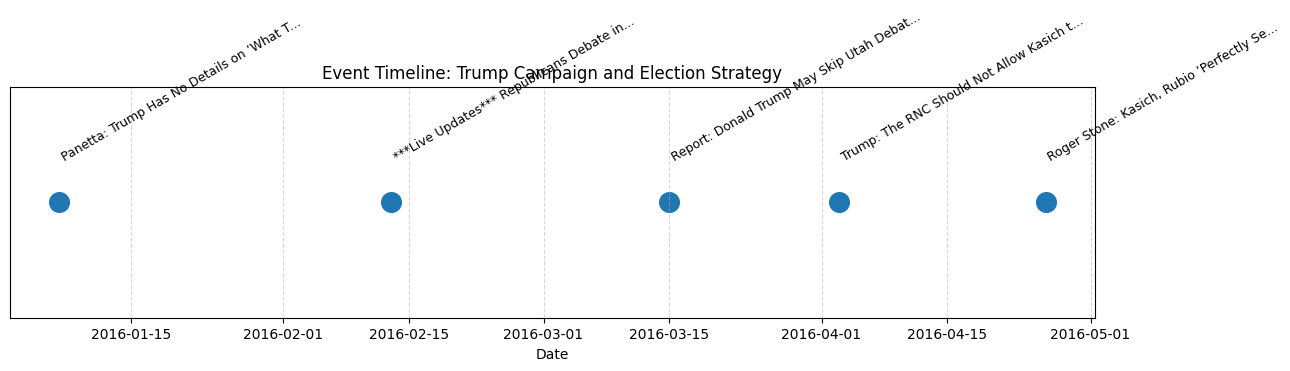

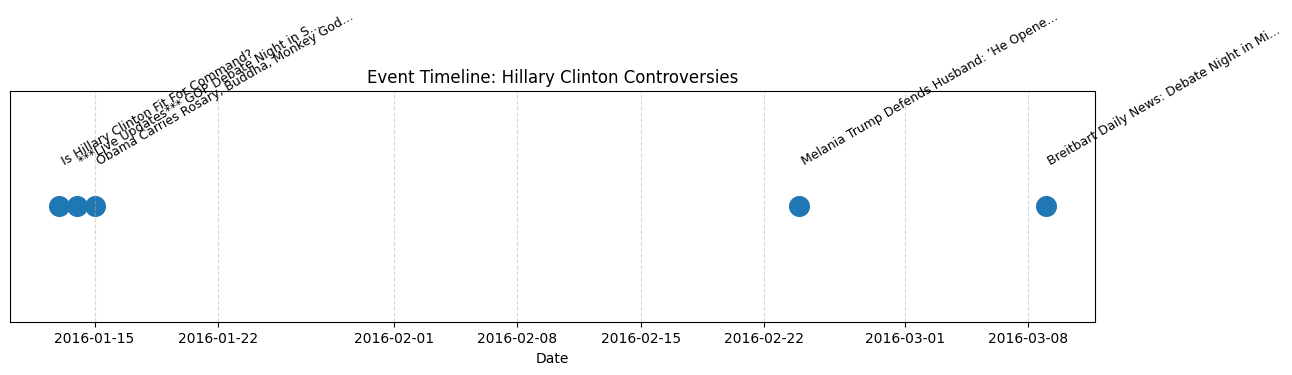

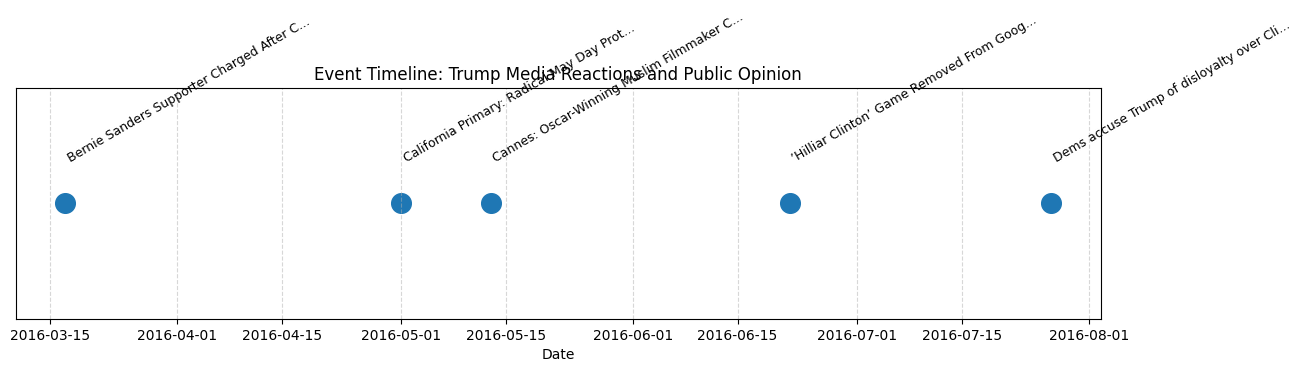

In [ ]:
import matplotlib.pyplot as plt

# visualize timelines for first 3 major events
for cluster_num in range(3):

    cluster_articles = df[df['cluster'] == cluster_num]

    # sort by date
    cluster_articles = cluster_articles.sort_values(by='date')

    # select important timeline events
    timeline_events = cluster_articles.head(5)

    plt.figure(figsize=(14, 3))

    # create horizontal timeline
    dates = timeline_events['date']
    y = [1] * len(dates)

    plt.scatter(dates, y, s=200)

    # add event titles
    for i, (_, row) in enumerate(timeline_events.iterrows()):

        title = row['title'].split(" - ")[0]

        # shorten long titles
        if len(title) > 40:
            title = title[:40] + "..."

        plt.text(
            row['date'],
            1.02,
            title,
            rotation=30,
            ha='left',
            fontsize=9
        )

    plt.yticks([])

    plt.title(f"Event Timeline: {event_labels[cluster_num]}")

    plt.xlabel("Date")

    plt.grid(axis='x', linestyle='--', alpha=0.5)

    plt.show()

In [ ]:
!pip install streamlit pyngrok

In [ ]:
# APP

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------
# PAGE TITLE
# --------------------------------

st.title("📰 AI News Event Clustering System")

st.write(
    "This dashboard displays clustered news events, "
    "event timelines, summaries, and related articles."
)

# --------------------------------
# EVENT LABELS
# --------------------------------

event_labels = {
    0: "Trump Campaign and Election Strategy",
    1: "Hillary Clinton Controversies",
    2: "Trump Media Reactions and Public Opinion",
    3: "Race Politics and Black Lives Matter",
    4: "Republican Support and Trump Movement"
}

# --------------------------------
# LOAD DATA
# --------------------------------

df = pd.read_csv("cleaned_news.csv")

df['date'] = pd.to_datetime(df['date'])

# --------------------------------
# SELECT EVENT
# --------------------------------

selected_cluster = st.selectbox(
    "Select Event Group",
    list(event_labels.keys()),
    format_func=lambda x: event_labels[x]
)

# filter cluster
cluster_articles = df[df['cluster'] == selected_cluster]

# sort by date
cluster_articles = cluster_articles.sort_values(by='date')

# --------------------------------
# EVENT SUMMARY
# --------------------------------

st.header("📌 Event Summary")

summaries = {
    0: "This event focused on Donald Trump’s campaign strategy, debates, immigration discussions, and political developments during the 2016 election.",

    1: "This event covered controversies surrounding Hillary Clinton, including campaign criticism, public reactions, and political debates.",

    2: "This event highlighted media reactions, protests, and public opinion related to Donald Trump during the election season.",

    3: "This event focused on race politics, Black Lives Matter discussions, and political responses during the 2016 election.",

    4: "This event included Republican support movements, anti-Trump campaigns, and political strategy discussions."
}

st.write(summaries[selected_cluster])

# --------------------------------
# EVENT TIMELINE
# --------------------------------

st.header("📅 Event Timeline")

timeline_articles = cluster_articles.head(5)

fig, ax = plt.subplots(figsize=(12, 3))

dates = timeline_articles['date']
y = [1] * len(dates)

ax.scatter(dates, y, s=200)

for i, (_, row) in enumerate(timeline_articles.iterrows()):

    title = row['title'].split(" - ")[0]

    if len(title) > 40:
        title = title[:40] + "..."

    ax.text(
        row['date'],
        1.02,
        title,
        rotation=25,
        fontsize=9
    )

ax.set_yticks([])

ax.set_title(event_labels[selected_cluster])

ax.grid(axis='x', linestyle='--', alpha=0.5)

st.pyplot(fig)

# --------------------------------
# ARTICLES INSIDE EVENT
# --------------------------------

st.header("📰 Articles Inside Event")

for i, (_, row) in enumerate(cluster_articles.iterrows(), 1):

    st.subheader(f"{i}. {row['title']}")

    st.write(f"📅 Date: {row['date'].date()}")

    st.write(f"🏢 Source: {row['publication']}")

    st.write("---")

Overwriting app.py


In [ ]:
df.to_csv("cleaned_news.csv", index=False)